# Practice 13 - Training Example

기본 학습 파이프라인에 **일반적으로 도입되는 기법들** (가중치 초기화 · BatchNorm · Dropout · L2 weight decay) 을 한꺼번에 적용해서, 학습이 얼마나 개선되는지 한눈에 봅니다.

| 모델 | 적용 기법 |
|------|-----------|
| **Baseline** | 기본 MLP, 추가 기법 없음 |
| **Improved** | He 초기화 + BatchNorm + Dropout(0.3) + L2 (weight_decay=1e-3) |

같은 데이터·같은 학습 횟수에서 Validation/Test 성능이 어떻게 달라지는지 비교합니다.


In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 데이터 준비 - 60/20/20 train/val/test 분할
digits = load_digits()
X = digits.data
y = digits.target

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# 표준화 - train 통계량을 val, test 에 동일 적용
train_mean = X_train.mean(axis=0)
train_std  = X_train.std(axis=0)
train_std[train_std == 0] = 1.0
X_train = (X_train - train_mean) / train_std
X_val   = (X_val   - train_mean) / train_std
X_test  = (X_test  - train_mean) / train_std

train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train)),
    batch_size=16, shuffle=True)
val_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val)),
    batch_size=16, shuffle=False)
test_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test)),
    batch_size=16, shuffle=False)

print(f'device: {device}, Train: {len(y_train)}, Val: {len(y_val)}, Test: {len(y_test)}')


device: cuda, Train: 1077, Val: 360, Test: 360


---
## `train` / `evaluate` 함수

학습 중에는 **val_loader** 로만 모니터링하며, test_loader 는 학습이 모두 끝난 뒤 별도로 한 번만 호출합니다.

In [2]:
# 학습 - epochs 만큼 학습 + 매 epoch val 평가
# (train_losses, train_accs, val_losses, val_accs) 반환
def train(model, train_loader, val_loader, optimizer, epochs, device):
    criterion = nn.CrossEntropyLoss()
    train_losses, train_accs, val_losses, val_accs = [], [], [], []
    for epoch in range(epochs):
        model.train()
        loss_sum, correct, count = 0.0, 0, 0
        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, Y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_sum += loss.item()
            correct += (output.argmax(1) == Y_batch).sum().item()
            count += len(Y_batch)
        train_loss = loss_sum / len(train_loader)
        train_acc = correct / count
        val_loss, val_acc, _ = evaluate(model, val_loader, device)   # y_pred 버림
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
    return train_losses, train_accs, val_losses, val_accs


# 평가 - (loss, accuracy, y_pred) 반환
def evaluate(model, loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    loss_sum, correct, count = 0.0, 0, 0
    preds = []
    with torch.no_grad():
        for X_batch, Y_batch in loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            output = model(X_batch)
            loss_sum += criterion(output, Y_batch).item()
            correct += (output.argmax(1) == Y_batch).sum().item()
            count += len(Y_batch)
            preds.append(output.argmax(1).cpu())
    y_pred = torch.cat(preds).numpy()
    return loss_sum / len(loader), correct / count, y_pred


---
# 1. Baseline - 기본 MLP (추가 기법 없음)

In [3]:
torch.manual_seed(42)
model_baseline = nn.Sequential(
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 10)
).to(device)
optimizer_baseline = torch.optim.Adam(model_baseline.parameters(), lr=1e-3)
train_losses_baseline, train_accs_baseline, val_losses_baseline, val_accs_baseline = train(model_baseline, train_loader, val_loader, optimizer_baseline, epochs=50, device=device)
print(f'Baseline final  val_loss={val_losses_baseline[-1]:.4f}  val_acc={val_accs_baseline[-1]:.4f}')


Baseline final  val_loss=0.0339  val_acc=0.9778


---
# 2. Improved - He 초기화 + BatchNorm + Dropout + L2

- **He 초기화** (Kaiming): ReLU 와 짝, 깊은 네트워크에서 gradient 폭주/소멸 완화
- **BatchNorm1d**: 층 출력 분포 안정화
- **Dropout(0.3)**: 학습 시 노드 30% 랜덤 비활성화 → 과적합 억제
- **L2 (weight_decay=1e-3)**: 가중치 크기에 벌칙 → 더 부드러운 결정 경계


In [4]:
torch.manual_seed(42)
model_improved = nn.Sequential(
    nn.Linear(64, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(128, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(128, 10)
)
# He(Kaiming) 초기화 - ReLU와 짝
for m in model_improved:
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
model_improved = model_improved.to(device)
optimizer_improved = torch.optim.Adam(model_improved.parameters(), lr=1e-3, weight_decay=1e-3)
train_losses_improved, train_accs_improved, val_losses_improved, val_accs_improved = train(model_improved, train_loader, val_loader, optimizer_improved, epochs=50, device=device)
print(f'Improved final  val_loss={val_losses_improved[-1]:.4f}  val_acc={val_accs_improved[-1]:.4f}')


Improved final  val_loss=0.1130  val_acc=0.9778


---
# 3. 비교 - Validation Loss / Accuracy

두 모델의 **Validation** 곡선만 비교합니다. 학습 곡선까지 같이 그리면 선이 너무 많아져 가독성이 떨어지므로, 일반화 성능 지표인 val 만 표시.

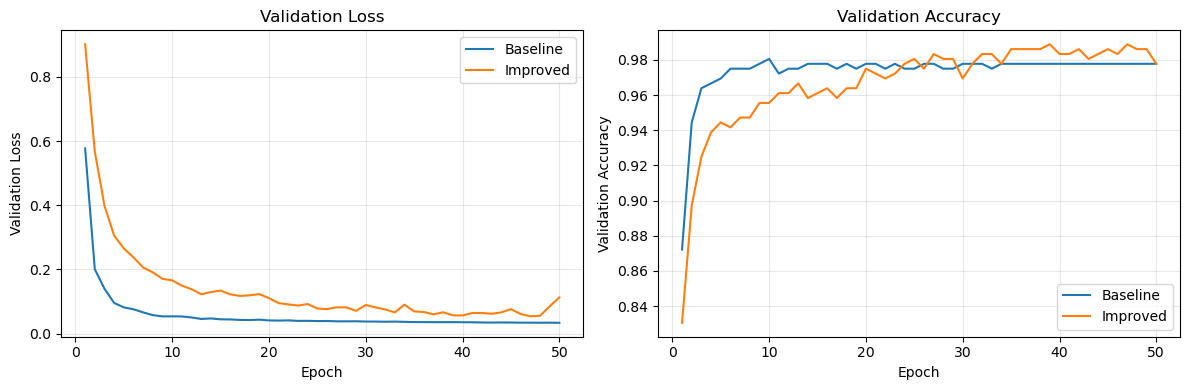

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(val_losses_baseline) + 1)

axes[0].plot(epochs_range, val_losses_baseline, label='Baseline')
axes[0].plot(epochs_range, val_losses_improved,  label='Improved')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Validation Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, val_accs_baseline, label='Baseline')
axes[1].plot(epochs_range, val_accs_improved,  label='Improved')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


---
# 4. 최종 Test 평가

두 모델 모두 학습이 끝났습니다. 학습 중에 한 번도 보지 않은 test set 에서 각각 평가합니다.

In [6]:
baseline_test_loss, baseline_test_acc, _      = evaluate(model_baseline, test_loader, device)
improved_test_loss,  improved_test_acc,  y_pred = evaluate(model_improved,  test_loader, device)

print(f'Baseline  test_loss={baseline_test_loss:.4f}  test_acc={baseline_test_acc:.4f}')
print(f'Improved  test_loss={improved_test_loss:.4f}  test_acc={improved_test_acc:.4f}')


Baseline  test_loss=0.1368  test_acc=0.9694
Improved  test_loss=0.0671  test_acc=0.9778


---
# 5. 훈련 결과 시각화 (Improved 모델)

직전 셀에서 받은 `y_pred` (Improved 모델 기준) 로 (재예측 없이) 두 가지를 함께 봅니다.

- **틀린 예측 4 개**: 1 × 4 그리드, 제목 `True:X / Pred:Y` (빨강)
- **Confusion Matrix**: 어떤 숫자가 어떤 숫자로 오인되는지

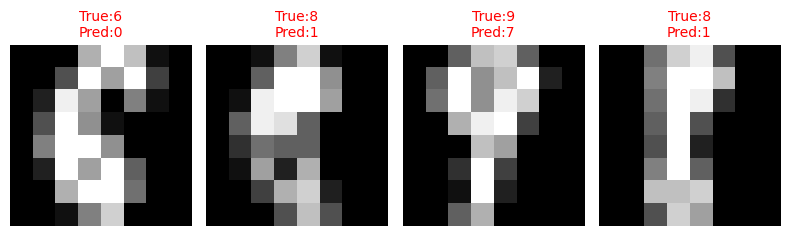

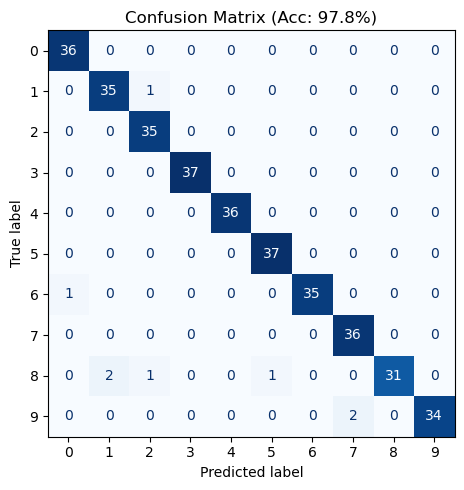

In [7]:

# (1) 틀린 예측 4 개 - 1 x 4 subplot
wrong_idx = np.where(y_pred != y_test)[0]
X_test_display = X_test * train_std + train_mean   # 표준화 역변환 - 원본 픽셀 (0~16) 로 복원
fig, axes = plt.subplots(1, 4, figsize=(8, 2.5))
for i in range(min(4, len(wrong_idx))):
    idx = wrong_idx[i]
    axes[i].imshow(X_test_display[idx].reshape(8, 8), cmap='gray')
    axes[i].set_title(f'True:{y_test[idx]}\nPred:{y_pred[idx]}', color='red', fontsize=10)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

# (2) Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix (Acc: {improved_test_acc:.1%})')
plt.tight_layout(); plt.show()


---
## 정리

기본 MLP 에 표준 기법 4가지만 추가해도 일반화 성능이 개선됩니다.

| 기법 | 효과 |
|------|------|
| He 초기화 | 깊은 네트워크에서 gradient 폭주/소멸 완화 |
| BatchNorm | 층 출력 분포 안정화 |
| Dropout | 학습 시 노드 랜덤 비활성화 → 과적합 억제 |
| L2 (weight decay) | 가중치 크기에 벌칙 → 부드러운 결정 경계 |
